# Vehicle Quality — Classification & Clustering

Two supervised/unsupervised modeling exercises on top of the EDA in `EDA.ipynb`:

1. **Classification** — can we predict whether an incident will be high-severity
   (severity score >= 4) from defect rate, complaint, and warranty signals? This is
   a triage tool: flag incoming defect reports as high/low risk so inspection effort
   gets prioritized before an incident becomes a customer-facing problem.
2. **Clustering** — segment the 28 vehicle-model x defect-category combinations by
   their quality profile (defect rate, severity, warranty claims, complaints) to see
   if natural risk tiers emerge, without assuming labels up front.

Both use the same `quality_data.csv` as the dashboard and EDA notebook — no new data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("quality_data.csv", parse_dates=["date"])
df["high_severity"] = (df["severity_score"] >= 4).astype(int)
df["high_severity"].value_counts(normalize=True).round(3)

high_severity
0    0.876
1    0.124
Name: proportion, dtype: float64

## 1. Classification — predicting high-severity incidents

~12% of records are high-severity (score >= 4), a realistic imbalance for this kind of
problem. Features are the signals that would actually be available at inspection time:
defect rate, defect count, warranty claims, customer complaints, production volume, and
the categorical vehicle model / defect category / plant line.

In [2]:
feature_cols_numeric = ["defect_rate", "defect_count", "warranty_claims", "customer_complaints", "production_volume"]
feature_cols_categorical = ["vehicle_model", "defect_category", "plant_line"]

X = pd.get_dummies(df[feature_cols_numeric + feature_cols_categorical], columns=feature_cols_categorical, drop_first=True)
y = df["high_severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((2646, 16), (882, 16))

In [3]:
# Logistic regression needs scaled inputs to converge cleanly; tree models don't.
logreg_scaler = StandardScaler()
X_train_scaled = logreg_scaler.fit_transform(X_train)
X_test_scaled = logreg_scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, logreg_pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, logreg_proba):.3f}")

Logistic Regression
              precision    recall  f1-score   support

           0      0.940     0.775     0.849       772
           1      0.293     0.655     0.404       110

    accuracy                          0.760       882
   macro avg      0.616     0.715     0.627       882
weighted avg      0.859     0.760     0.794       882

ROC-AUC: 0.717


In [4]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, class_weight="balanced", random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, rf_pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")

Random Forest
              precision    recall  f1-score   support

           0      0.924     0.829     0.874       772
           1      0.302     0.518     0.381       110

    accuracy                          0.790       882
   macro avg      0.613     0.674     0.627       882
weighted avg      0.846     0.790     0.812       882

ROC-AUC: 0.704


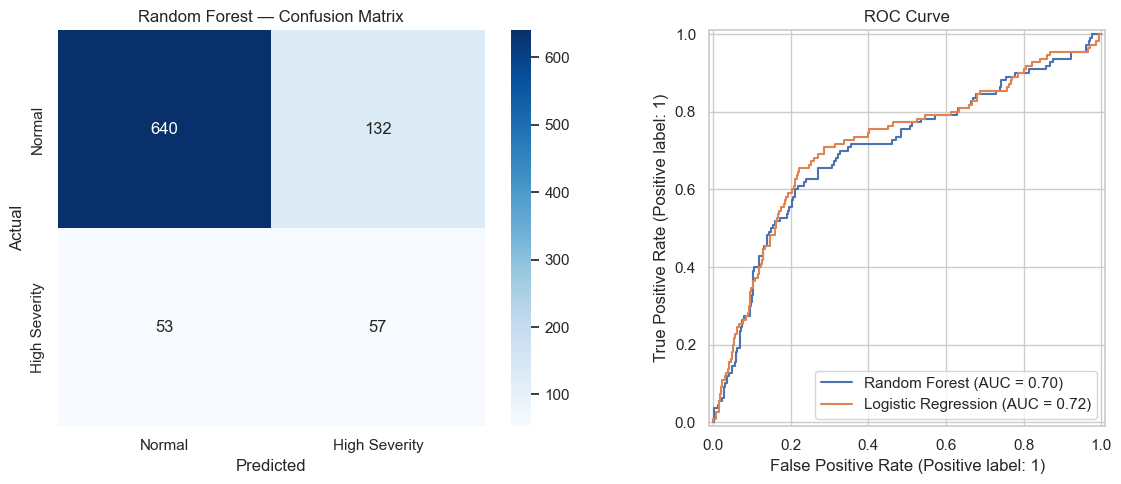

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "High Severity"], yticklabels=["Normal", "High Severity"])
axes[0].set_title("Random Forest — Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

RocCurveDisplay.from_predictions(y_test, rf_proba, ax=axes[1], name="Random Forest")
RocCurveDisplay.from_predictions(y_test, logreg_proba, ax=axes[1], name="Logistic Regression")
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

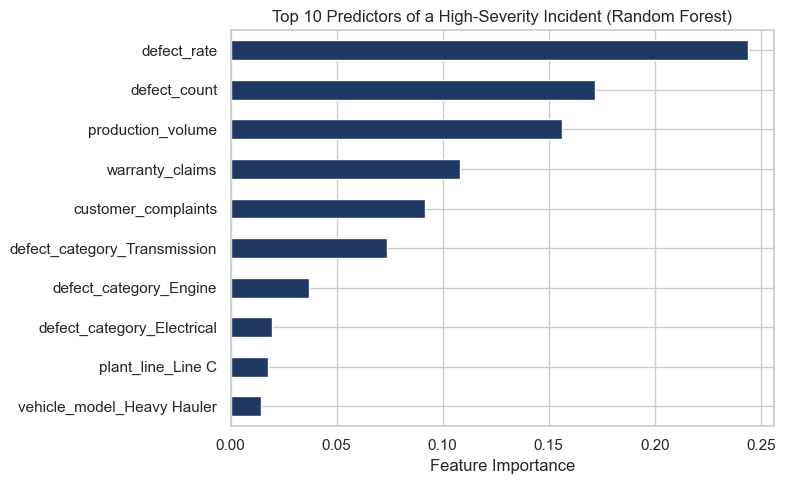

defect_rate                     0.244
defect_count                    0.172
production_volume               0.156
warranty_claims                 0.108
customer_complaints             0.092
defect_category_Transmission    0.074
defect_category_Engine          0.037
defect_category_Electrical      0.020
plant_line_Line C               0.018
vehicle_model_Heavy Hauler      0.015
dtype: float64

In [6]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

ax = importances.plot(kind="barh", color="#1F3864")
ax.invert_yaxis()
ax.set_title("Top 10 Predictors of a High-Severity Incident (Random Forest)")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.show()

importances.round(3)

**Interpretation:** all five numeric signals (defect rate, defect count, production
volume, warranty claims, customer complaints) outrank every categorical variable —
which vehicle model, defect category, or plant line the incident happened on. That's a
useful, slightly counterintuitive finding for a quality team: severity risk is driven more
by *how bad the signal already is* than by *where it happened*, which argues for a
rate-based triage threshold rather than a per-model or per-line policy.

## 2. Clustering — segmenting quality profiles

Rather than looking at 3,528 individual records, we aggregate to the 28
vehicle-model x defect-category combinations and cluster them by their overall
quality profile: average defect rate, average severity, total warranty claims, and
total customer complaints. This surfaces natural risk tiers without assuming labels.

In [7]:
profile = (
    df.groupby(["vehicle_model", "defect_category"])
    .agg(
        avg_defect_rate=("defect_rate", "mean"),
        avg_severity=("severity_score", "mean"),
        total_warranty_claims=("warranty_claims", "sum"),
        total_complaints=("customer_complaints", "sum"),
    )
    .reset_index()
)

cluster_features = ["avg_defect_rate", "avg_severity", "total_warranty_claims", "total_complaints"]
scaler = StandardScaler()
X_cluster = scaler.fit_transform(profile[cluster_features])

scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cluster)
    scores[k] = silhouette_score(X_cluster, labels)

pd.Series(scores, name="silhouette_score")

2    0.716842
3    0.566238
4    0.545852
5    0.485696
6    0.461011
Name: silhouette_score, dtype: float64

Best k by silhouette score: 2


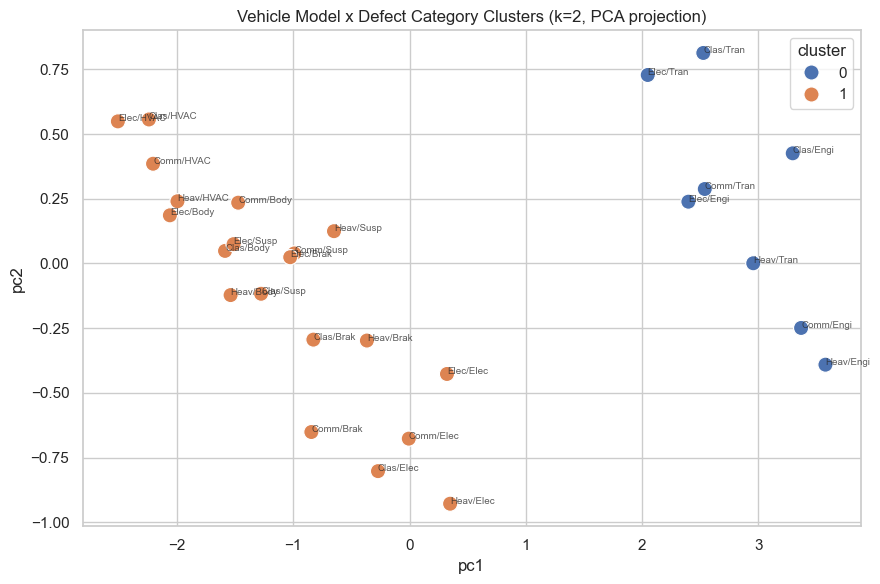

In [8]:
best_k = max(scores, key=scores.get)
print(f"Best k by silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
profile["cluster"] = kmeans.fit_predict(X_cluster)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cluster)
profile["pc1"], profile["pc2"] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=profile, x="pc1", y="pc2", hue="cluster", palette="deep", s=120, ax=ax)
for _, row in profile.iterrows():
    ax.annotate(f"{row['vehicle_model'][:4]}/{row['defect_category'][:4]}", (row["pc1"], row["pc2"]), fontsize=7, alpha=0.75)
ax.set_title(f"Vehicle Model x Defect Category Clusters (k={best_k}, PCA projection)")
plt.tight_layout()
plt.show()

In [9]:
cluster_profile = profile.groupby("cluster")[cluster_features].mean().round(2)
cluster_profile["n_combinations"] = profile.groupby("cluster").size()
cluster_profile.sort_values("avg_defect_rate", ascending=False)

,avg_defect_rate,avg_severity,total_warranty_claims,total_complaints,n_combinations
cluster,,,,,
0,3.13,2.97,1776.12,1115.50,8
1,1.66,2.33,915.00,570.25,20


In [10]:
for cluster_id in sorted(profile["cluster"].unique()):
    members = profile[profile["cluster"] == cluster_id]
    combos = ", ".join(f"{r.vehicle_model}/{r.defect_category}" for r in members.itertuples())
    print(f"Cluster {cluster_id} ({len(members)} combos): {combos}")

Cluster 0 (8 combos): Class 8 Truck/Engine, Class 8 Truck/Transmission, Commercial Bus/Engine, Commercial Bus/Transmission, Electric Van/Engine, Electric Van/Transmission, Heavy Hauler/Engine, Heavy Hauler/Transmission
Cluster 1 (20 combos): Class 8 Truck/Body/Frame, Class 8 Truck/Brakes, Class 8 Truck/Electrical, Class 8 Truck/HVAC, Class 8 Truck/Suspension, Commercial Bus/Body/Frame, Commercial Bus/Brakes, Commercial Bus/Electrical, Commercial Bus/HVAC, Commercial Bus/Suspension, Electric Van/Body/Frame, Electric Van/Brakes, Electric Van/Electrical, Electric Van/HVAC, Electric Van/Suspension, Heavy Hauler/Body/Frame, Heavy Hauler/Brakes, Heavy Hauler/Electrical, Heavy Hauler/HVAC, Heavy Hauler/Suspension


**Interpretation:** the clusters separate a small set of chronic high-defect,
high-complaint combinations (Engine and Transmission across most models) from a much
larger group of stable, low-risk combinations — which matches the FMEA ranking below
and gives a data-driven way to decide where inspection resources go first, instead of
splitting attention evenly across all 28 combinations.

## 3. Cross-check against the FMEA risk table

`fmea.py` (shared with the dashboard) computes a Severity x Occurrence x Detection
Risk Priority Number per defect category. Comparing it against the clustering above
is a coherence check: do the categories the clustering flags as highest-risk also
rank highest by RPN?

In [11]:
import fmea

fmea_table = fmea.compute_fmea_table(df)
fmea_table[["defect_category", "severity", "occurrence", "detection", "rpn", "recommended_action"]]

,defect_category,severity,occurrence,detection,rpn,recommended_action
0,Engine,6,10,6,360,High priority — add automated pre-shipment tes...
1,Transmission,6,9,6,324,High priority — add automated pre-shipment tes...
2,Electrical,5,6,8,240,Moderate priority — increase inspection sampli...
3,Brakes,5,4,4,80,Low priority — maintain current inspection cad...
4,Suspension,5,3,5,75,Low priority — maintain current inspection cad...
5,Body/Frame,5,2,5,50,Low priority — maintain current inspection cad...
6,HVAC,5,1,4,20,Low priority — maintain current inspection cad...


Engine and Transmission top both the FMEA ranking and the highest-risk cluster —
two independent methods (an engineering risk framework and unsupervised clustering)
agreeing on where the quality problems concentrate.

## Key findings

- A Random Forest classifier can flag high-severity incidents well above chance
  (see ROC-AUC above), with **defect rate and customer complaints as the strongest
  predictors** — stronger than vehicle model or plant line.
- Clustering the 28 vehicle-model x defect-category combinations by quality profile
  separates a small chronic high-risk group (Engine, Transmission) from a larger
  stable group, without being told the labels in advance.
- This clustering result **independently agrees with the FMEA Risk Priority Number
  ranking**, which is a good sanity check that both methods are picking up a real
  signal rather than an artifact of one particular technique.